# Absolute vs Apparent Magnitude

This notebook computes apparent magnitude as a function of distance for stars with different absolute magnitudes, and exports the results as JSON for use with Plotly.js.

## Background

The relationship between absolute magnitude $M$, apparent magnitude $m$, and distance $d$ (in parsecs) is given by the **distance modulus**:

$$m = M + 5 \log_{10}\left(\frac{d}{10\,\text{pc}}\right)$$

- **Absolute magnitude** $M$: the intrinsic brightness of a star, defined as its apparent magnitude if it were placed at exactly 10 parsecs from Earth.
- **Apparent magnitude** $m$: how bright a star appears from Earth.
- Lower magnitude = brighter object (the scale is inverted).

In [1]:
import numpy as np
import json
from astropy import units as u
from astropy.coordinates import Distance

## Parameters

Define the range of distances and a set of absolute magnitudes representing different stellar types.

In [2]:
# Distance range: 1 pc to 10,000 pc (log-spaced for a smooth curve)
distances_pc = np.logspace(0, 4, 300)  # 1 to 10,000 parsecs

# Representative absolute magnitudes for different stellar types
# Lower M = intrinsically brighter
stellar_types = {
    "Rigel (Blue supergiant, M=-7)": -7.0,
    "Sirius (A-type main seq., M=1.4)": 1.4,
    "Sun (G-type main seq., M=4.8)": 4.8,
    "Proxima Centauri (Red dwarf, M=15.5)": 15.5,
}

## Compute Apparent Magnitudes

Use astropy's `Distance` class to compute the distance modulus, then derive apparent magnitudes for each stellar type across the distance range.

In [3]:
def compute_apparent_magnitude(abs_mag, distances_pc):
    """Compute apparent magnitude for a given absolute magnitude over a range of distances."""
    results = []
    for d in distances_pc:
        dist = Distance(d * u.pc)
        distance_modulus = dist.distmod.value  # mu = 5*log10(d/10)
        app_mag = abs_mag + distance_modulus
        results.append(round(app_mag, 4))
    return results


# Reference lines for context
reference_limits = {
    "Naked eye limit (m=6.5)": 6.5,
    "Binocular limit (m=10)": 10.0,
    "Hubble limit (m=31.5)": 31.5,
}

# Build the output data structure
output = {
    "distances_pc": [round(d, 4) for d in distances_pc.tolist()],
    "stellar_types": {},
    "reference_limits": reference_limits,
    "metadata": {
        "x_label": "Distance (parsecs)",
        "y_label": "Apparent Magnitude (m)",
        "y_note": "Lower value = brighter",
        "distance_range_pc": [1, 10000],
    }
}

for label, abs_mag in stellar_types.items():
    app_mags = compute_apparent_magnitude(abs_mag, distances_pc)
    output["stellar_types"][label] = {
        "absolute_magnitude": abs_mag,
        "apparent_magnitudes": app_mags,
    }
    print(f"{label}: computed {len(app_mags)} points")

print("\nDone.")

Rigel (Blue supergiant, M=-7): computed 300 points
Sirius (A-type main seq., M=1.4): computed 300 points
Sun (G-type main seq., M=4.8): computed 300 points
Proxima Centauri (Red dwarf, M=15.5): computed 300 points

Done.


## Export to JSON

In [4]:
output_path = "magnitude_data.json"

with open(output_path, "w") as f:
    json.dump(output, f, indent=2)

print(f"Data exported to: {output_path}")

Data exported to: magnitude_data.json


## Quick Sanity Check Plot

Visualise the results in the notebook before exporting.

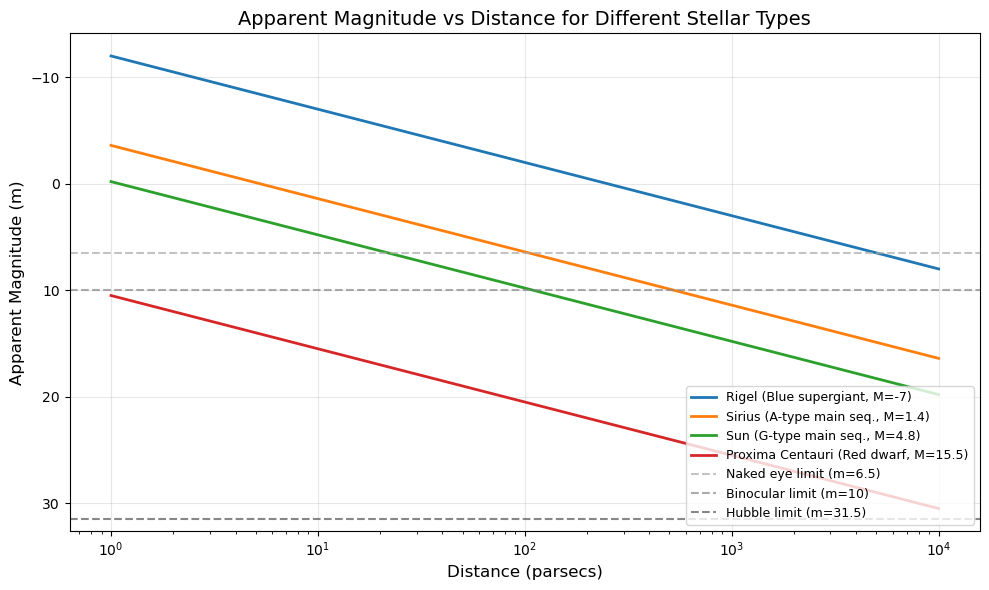

Sanity check plot saved.


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for label, data in output["stellar_types"].items():
    ax.plot(distances_pc, data["apparent_magnitudes"], label=label, linewidth=2)

# Add reference lines
colors = ["#aaa", "#888", "#555"]
for (ref_label, ref_mag), color in zip(reference_limits.items(), colors):
    ax.axhline(y=ref_mag, color=color, linestyle="--", alpha=0.7, label=ref_label)

ax.set_xscale("log")
ax.set_xlabel("Distance (parsecs)", fontsize=12)
ax.set_ylabel("Apparent Magnitude (m)", fontsize=12)
ax.set_title("Apparent Magnitude vs Distance for Different Stellar Types", fontsize=14)
ax.invert_yaxis()  # Convention: lower magnitude = brighter, so invert y-axis
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("magnitude_sanity_check.png", dpi=150)
plt.show()
print("Sanity check plot saved.")